<a href="https://colab.research.google.com/github/StudentbcuAKR/Cybersecurity/blob/main/cybersecurity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import pandas for data manipulation and analysis
# import pandas so we can work with tables
import pandas as pd

# load 50,000 rows from your dataset
df = pd.read_csv('/content/drive/MyDrive/cicids2017_cleaned.csv', nrows=50000)

# check size of the dataset
print("Dataset shape:", df.shape)

# look at column names
print(df.columns)

Dataset shape: (50000, 53)
Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Length of Fwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd Header Length', 'Bwd Header Length',
       'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length',
       'Max Packet Length', 'Packet Length Mean', 'Packet Length Std',
       'Packet Length Variance', 'FIN Flag Count', 'PSH Flag Count',
       'ACK Flag Count', 'Average Packet Size', 'Subflow Fwd Bytes',
       'Init_Win_bytes_forward', 'Init_Win_b

In [ ]:
# X = This basically inputs the  data
# y = While this will answer what we want to predict
X = df.drop('Attack Type', axis=1)
y = df['Attack Type']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (50000, 52)
y shape: (50000,)


In [ ]:
# machine learning models need numbers, not words
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

# check the classes
print("Classes:", le.classes_)

Classes: ['Normal Traffic' 'Port Scanning']


In [ ]:
# split data into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (40000, 52)
Test shape: (10000, 52)


In [ ]:
# scaling puts all numbers on a similar size
# this helps models like Logistic Regression, SVM, ANN, LSTM
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit on train, then use same settings on test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# these help us check model performance
from sklearn.metrics import accuracy_score, classification_report

In [ ]:

from sklearn.linear_model import LogisticRegression

# simple baseline model
lr = LogisticRegression(max_iter=2000)

# train the model
lr.fit(X_train_scaled, y_train)

# make predictions
y_pred_lr = lr.predict(X_test_scaled)

# print results
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr, zero_division=0))

Logistic Regression Accuracy: 0.9991
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9958
           1       0.87      0.93      0.90        42

    accuracy                           1.00     10000
   macro avg       0.93      0.96      0.95     10000
weighted avg       1.00      1.00      1.00     10000



In [ ]:
from sklearn.tree import DecisionTreeClassifier

# tree model
dt = DecisionTreeClassifier(random_state=42)

# train the model
dt.fit(X_train_scaled, y_train)

# make predictions
y_pred_dt = dt.predict(X_test_scaled)

# print results
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt, zero_division=0))

Decision Tree Accuracy: 0.9997
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9958
           1       1.00      0.93      0.96        42

    accuracy                           1.00     10000
   macro avg       1.00      0.96      0.98     10000
weighted avg       1.00      1.00      1.00     10000



In [ ]:
from sklearn.ensemble import RandomForestClassifier

# forest = many trees together
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# train the model
rf.fit(X_train_scaled, y_train)

# make predictions
y_pred_rf = rf.predict(X_test_scaled)

# print results
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, zero_division=0))

Random Forest Accuracy: 0.9998
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9958
           1       1.00      0.95      0.98        42

    accuracy                           1.00     10000
   macro avg       1.00      0.98      0.99     10000
weighted avg       1.00      1.00      1.00     10000



In [ ]:
from sklearn.svm import SVC

# SVM model
svm = SVC()

# train the model
svm.fit(X_train_scaled, y_train)

# make predictions
y_pred_svm = svm.predict(X_test_scaled)

# print results
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm, zero_division=0))

SVM Accuracy: 0.9983
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9958
           1       0.90      0.67      0.77        42

    accuracy                           1.00     10000
   macro avg       0.95      0.83      0.88     10000
weighted avg       1.00      1.00      1.00     10000



In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

# build a simple ANN
ann = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),  # number of input features
    Dense(32, activation='relu'),             # first hidden layer
    Dense(16, activation='relu'),             # second hidden layer
    Dense(1, activation='sigmoid')            # output for binary class
])

# tell the model how to learn
ann.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# train the model
ann.fit(X_train_scaled, y_train, epochs=5, batch_size=32, verbose=1)

# get test accuracy
loss_ann, acc_ann = ann.evaluate(X_test_scaled, y_test, verbose=0)
print("ANN Accuracy:", acc_ann)

# turn probabilities into 0 or 1
y_pred_ann = (ann.predict(X_test_scaled) > 0.5).astype("int32")

# print report
print(classification_report(y_test, y_pred_ann, zero_division=0))

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9908 - loss: 0.0336
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9976 - loss: 0.0053
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9996 - loss: 0.0027
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9997 - loss: 0.0019
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9996 - loss: 0.0017
ANN Accuracy: 0.9995999932289124
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 957us/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9958
           1       0.97      0.93      0.95        42

    accuracy                           1.00     10000
   macro avg       0.99      0.96      0.98     10000
weighted avg       1.00      1.00      1.00     10000



In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

# build a simple ANN
ann = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),  # number of input features
    Dense(32, activation='relu'),             # first hidden layer
    Dense(16, activation='relu'),             # second hidden layer
    Dense(1, activation='sigmoid')            # output for binary class
])

# tell the model how to learn
ann.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# train the model
ann.fit(X_train_scaled, y_train, epochs=5, batch_size=32, verbose=1)

# get test accuracy
loss_ann, acc_ann = ann.evaluate(X_test_scaled, y_test, verbose=0)
print("ANN Accuracy:", acc_ann)

# turn probabilities into 0 or 1
y_pred_ann = (ann.predict(X_test_scaled) > 0.5).astype("int32")

# print report
print(classification_report(y_test, y_pred_ann, zero_division=0))

import numpy as np
from tensorflow.keras.layers import LSTM

# LSTM needs 3D input:
# (rows, time steps, features per step)
X_train_lstm = np.reshape(
    X_train_scaled,
    (X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
)

X_test_lstm = np.reshape(
    X_test_scaled,
    (X_test_scaled.shape[0], X_test_scaled.shape[1], 1)
)

# build LSTM model
lstm = Sequential([
    Input(shape=(X_train_lstm.shape[1], 1)),
    LSTM(32),
    Dense(1, activation='sigmoid')
])

# compile model
lstm.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# train model
lstm.fit(X_train_lstm, y_train, epochs=5, batch_size=32, verbose=1)

# get test accuracy
loss_lstm, acc_lstm = lstm.evaluate(X_test_lstm, y_test, verbose=0)
print("LSTM Accuracy:", acc_lstm)

# make predictions
y_pred_lstm = (lstm.predict(X_test_lstm) > 0.5).astype("int32")

# print report
print(classification_report(y_test, y_pred_lstm, zero_division=0))

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9959 - loss: 0.0220
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9992 - loss: 0.0034
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9995 - loss: 0.0022
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9996 - loss: 0.0017
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9997 - loss: 0.0015
ANN Accuracy: 0.9995999932289124
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9958
           1       0.97      0.93      0.95        42

    accuracy                           1.00     10000
   macro avg       0.99      0.96      0.98     10000
weighted avg       1.00      1.00      1.00     10000

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.9944 - loss: 0.0420
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.9957 -

In [ ]:
# this helper function pulls out the attack-class scores
def get_attack_scores(y_true, y_pred, model_name):
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)

    # class "1" is the attack class after label encoding
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision_Attack": report["1"]["precision"],
        "Recall_Attack": report["1"]["recall"],
        "F1_Attack": report["1"]["f1-score"]
    }

# build results list
results = [
    get_attack_scores(y_test, y_pred_lr, "Logistic Regression"),
    get_attack_scores(y_test, y_pred_dt, "Decision Tree"),
    get_attack_scores(y_test, y_pred_rf, "Random Forest"),
    get_attack_scores(y_test, y_pred_svm, "SVM"),
    get_attack_scores(y_test, y_pred_ann, "ANN"),
    get_attack_scores(y_test, y_pred_lstm, "LSTM")
]

# turn into table
results_df = pd.DataFrame(results)

# show table
print(results_df)


                 Model  Accuracy  Precision_Attack  Recall_Attack  F1_Attack
0  Logistic Regression    0.9991          0.866667       0.928571   0.896552
1        Decision Tree    0.9997          1.000000       0.928571   0.962963
2        Random Forest    0.9998          1.000000       0.952381   0.975610
3                  SVM    0.9983          0.903226       0.666667   0.767123
4                  ANN    0.9996          0.975000       0.928571   0.951220
5                 LSTM    0.9958          0.000000       0.000000   0.000000


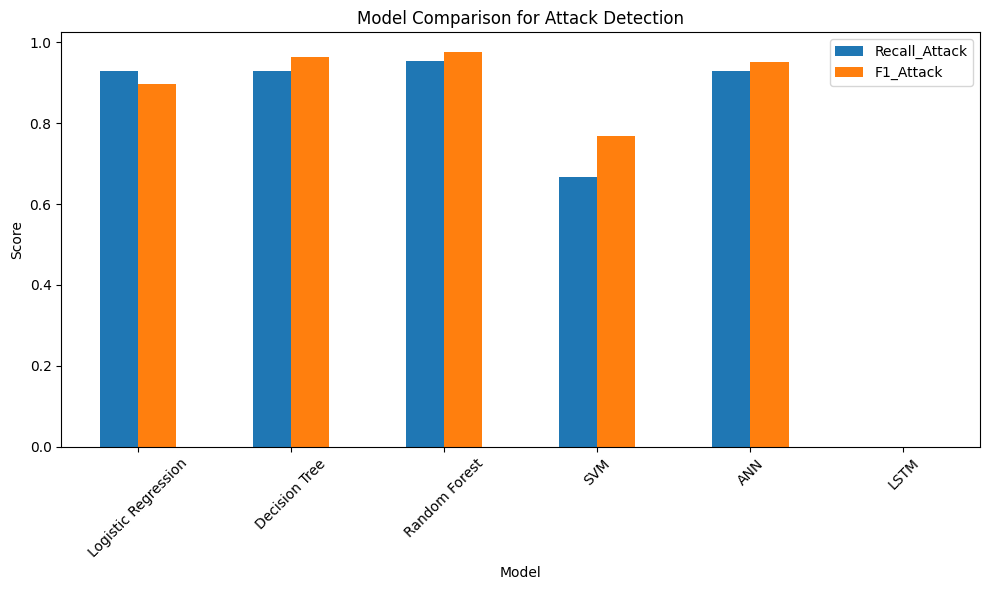

In [ ]:
import matplotlib.pyplot as plt

# compare recall and f1 for attack class
results_df.plot(
    x="Model",
    y=["Recall_Attack", "F1_Attack"],
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Comparison for Attack Detection")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()